# Customer Engagement Analysis
**365 Data Science — Practical Project**

Analysis of student engagement (minutes watched) in Q4 2021 vs Q4 2022, following the introduction of new platform features. Covers descriptive statistics, confidence intervals, and hypothesis testing for paid and free-plan students.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Task 1 — Descriptive Statistics: Low-Engagement Students (1–100 min in Q4 2021)

Comparing engagement in Q4 2021 vs Q4 2022 for students who watched between 1 and 100 minutes in 2021, split by paid and free plan.

In [ ]:
df = pd.read_excel('data/Engagement Project.xlsx', sheet_name='Task 1 and 2', header=None, skiprows=4)
df.drop(columns=[0, 5], inplace=True)
df.columns = df.iloc[0]
df.drop(index=0, inplace=True)
df1, df0 = df.iloc[:, :4].copy(), df.iloc[:, 4:].copy()
df1.dropna(inplace=True)
df0.dropna(inplace=True)
df1,df0

(0   student_id paid minutes_watched_21 minutes_watched_22
 1        16979    1              13.32             260.72
 2       207114    1              40.12             387.98
 3       156680    1              17.57             128.78
 4       149601    1              42.95             7417.4
 5       251499    1               4.92              10.47
 ..         ...  ...                ...                ...
 453     247130    1              13.78               0.07
 454       7031    1               7.97               0.37
 455     223701    1              28.38              40.28
 456     256834    1              13.77              69.08
 457       1711    1                2.4                0.1
 
 [457 rows x 4 columns],
 0    student_id paid minutes_watched_21 minutes_watched_22
 1        238865    0               1.43             157.28
 2        247592    0                3.1                0.1
 3        195373    0               8.45              12.57
 4        229324    0    

In [51]:
num_cols = ['minutes_watched_21', 'minutes_watched_22']

df1[num_cols] = df1[num_cols].apply(pd.to_numeric, errors='coerce')
df0[num_cols] = df0[num_cols].apply(pd.to_numeric, errors='coerce')


In [ ]:
# Ensure df1 is a DataFrame (it may have been overwritten elsewhere)
if not hasattr(df1, 'describe'):
	try:
		df1 = df.iloc[:, :4]
	except Exception as e:
		raise RuntimeError("df1 is not a DataFrame and could not be reconstructed from df") from e

df1_stats = df1.describe().T
df1_stats['mean'] = df1.mean()
df1_stats['median'] = df1.median()

modes = df1.mode()
if not modes.empty:
	df1_stats['mode'] = modes.iloc[0]
else:
	df1_stats['mode'] = pd.Series([np.nan] * len(df1.columns), index=df1.columns)

df1_stats['variance'] = df1.var()
df1_stats['standard_deviation'] = df1.std()
df1_stats

,count,unique,top,freq,mean,median,mode,variance,standard_deviation
0,,,,,,,,,
student_id,457.0,457.0,16979.00,1.0,141858.282276,161524.0,278,9523670970.834618,97589.29742
paid,457.0,1.0,1.00,457.0,1.0,1.0,1,0.0,0.0
minutes_watched_21,457.0,433.0,6.57,3.0,33.796958,26.33,6.57,796.004008,28.213543
minutes_watched_22,457.0,416.0,0.05,6.0,273.020503,40.28,0.05,730298.835489,854.575237


In [ ]:
df0_stats = df0.describe().T
df0_stats['mean'] = df0.mean()
df0_stats['median'] = df0.median()
df0_stats['mode'] = df0.mode().iloc[0]
df0_stats['standard_deviation'] = df0.std()
df0_stats

,count,unique,top,freq,mean,median,mode,variance,standard_deviation
0,,,,,,,,,
student_id,2065.0,2065.0,238865.00,1.0,190854.195642,202806.0,20,3486398766.817326,59045.734535
paid,2065.0,1.0,0.00,2065.0,0.0,0.0,0,0.0,0.0
minutes_watched_21,2065.0,1424.0,1.20,25.0,25.391676,14.17,1.2,688.093528,26.231537
minutes_watched_22,2065.0,1342.0,0.05,43.0,117.637458,11.83,0.05,219899.719938,468.934665


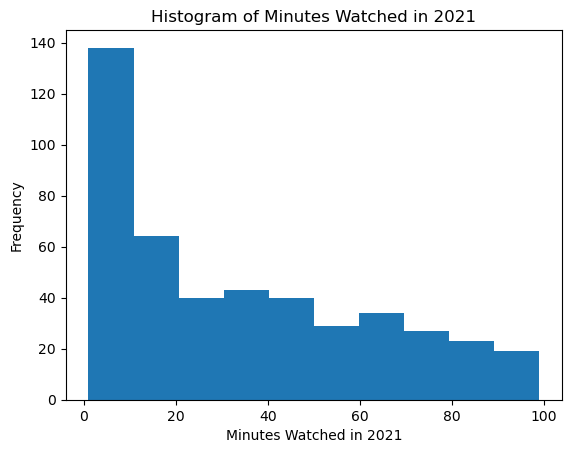

In [44]:
plt.hist(df1['minutes_watched_21'], bins=10)
plt.xlabel('Minutes Watched in 2021')
plt.ylabel('Frequency')
plt.title('Histogram of Minutes Watched in 2021')
plt.show()

(array([428.,  18.,   4.,   1.,   1.,   1.,   0.,   1.,   2.,   1.]),
 array([5.000000e-02, 9.214580e+02, 1.842866e+03, 2.764274e+03,
        3.685682e+03, 4.607090e+03, 5.528498e+03, 6.449906e+03,
        7.371314e+03, 8.292722e+03, 9.214130e+03]),
 <BarContainer object of 10 artists>)

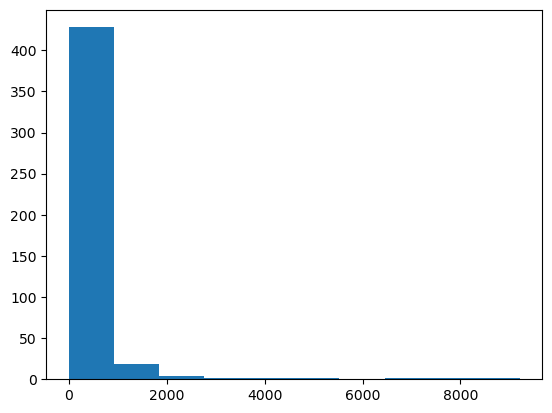

In [ ]:
plt.hist(df1['minutes_watched_22'], bins=10)
plt.xlabel('Minutes Watched in 2022')
plt.ylabel('Frequency')
plt.title('Histogram of Minutes Watched in 2022')
plt.show()

## Task 2 — Skewness and Kurtosis

Calculating skewness and kurtosis for paid and free students in both years to understand the shape of the distributions.

In [54]:
from scipy.stats import skew, kurtosis
skewness_21 = skew(df1['minutes_watched_21'])
kurtosis_21 = kurtosis(df1['minutes_watched_21'])
skewness_22 = skew(df1['minutes_watched_22'])
kurtosis_22 = kurtosis(df1['minutes_watched_22'])
skewness_210 = skew(df0['minutes_watched_21'])
kurtosis_210 = kurtosis(df0['minutes_watched_21'])
skewness_220 = skew(df0['minutes_watched_22'])
kurtosis_220 = kurtosis(df0['minutes_watched_22'])
df1_skw_krt = skewness_21, kurtosis_21, skewness_22, kurtosis_22
df0_skw_krt = skewness_210, kurtosis_210, skewness_220, kurtosis_220
df1_skw_krt, df0_skw_krt

((0.6231039033886645,
  -0.8531191386590518,
  7.042383202131584,
  57.83393566028901),
 (1.1668909715878173,
  0.3562576926451899,
  15.050733044485195,
  314.9978385374214))

## Task 3 — Confidence Intervals (95%, Z-statistic)

Computing 95% confidence intervals for average minutes watched for paid and free students in Q4 2021 and Q4 2022.

In [64]:
df3 = pd.read_excel('Engagement Project.xlsx', sheet_name='Task 3', header=None, skiprows=4)
df3.drop(columns=[0, 3], inplace=True)
df3.columns = df3.iloc[0]
df3_paid, df3_free = df3.iloc[:, :2].copy(), df3.iloc[:, 2:].copy()
df3_paid.dropna(how='all', inplace=True)
df3_free.dropna(how='all', inplace=True)
cols = ['minutes_watched_21', 'minutes_watched_22']

df3_paid[cols] = df3_paid[cols].apply(pd.to_numeric, errors='coerce')
df3_free[cols] = df3_free[cols].apply(pd.to_numeric, errors='coerce')

df3_paid, df3_free

(0     minutes_watched_21  minutes_watched_22
 0                    NaN                 NaN
 1                2973.67             4110.17
 2                2939.48             4099.42
 3                2860.78             4085.20
 4                2853.73             4064.35
 ...                  ...                 ...
 5100                 NaN                0.05
 5101                 NaN                0.05
 5102                 NaN                0.05
 5103                 NaN                0.05
 5104                 NaN                0.05
 
 [5105 rows x 2 columns],
 0       minutes_watched_21  minutes_watched_22
 0                      NaN                 NaN
 1                  4716.68             6338.07
 2                  4670.70             6280.12
 3                  4622.35             6250.32
 4                  4617.75             6208.80
 ...                    ...                 ...
 120654                 NaN                0.05
 120655                 NaN         

In [65]:
IC_paid1 = [df3_paid['minutes_watched_21'].mean() - 1.96 * (df3_paid['minutes_watched_21'].std() / np.sqrt(len(df3_paid['minutes_watched_21']))), df3_paid['minutes_watched_21'].mean() + 1.96 * (df3_paid['minutes_watched_21'].std() / np.sqrt(len(df3_paid['minutes_watched_21'])))]
IC_paid2 = [df3_paid['minutes_watched_22'].mean() - 1.96 * (df3_paid['minutes_watched_22'].std() / np.sqrt(len(df3_paid['minutes_watched_22']))), df3_paid['minutes_watched_22'].mean() + 1.96 * (df3_paid['minutes_watched_22'].std() / np.sqrt(len(df3_paid['minutes_watched_22'])))]
IC_free1 = [df3_free['minutes_watched_21'].mean() - 1.96 * (df3_free['minutes_watched_21'].std() / np.sqrt(len(df3_free['minutes_watched_21']))), df3_free['minutes_watched_21'].mean() + 1.96 * (df3_free['minutes_watched_21'].std() / np.sqrt(len(df3_free['minutes_watched_21'])))]
IC_free2 = [df3_free['minutes_watched_22'].mean() - 1.96 * (df3_free['minutes_watched_22'].std() / np.sqrt(len(df3_free['minutes_watched_22']))), df3_free['minutes_watched_22'].mean() + 1.96 * (df3_free['minutes_watched_22'].std() / np.sqrt(len(df3_free['minutes_watched_22'])))]
IC_paid1, IC_paid2, IC_free1, IC_free2

([319.17427901661404, 345.830737004359],
 [351.9941002520038, 384.7153276476829],
 [131.8610124196346, 136.0056134235161],
 [67.70528474638544, 70.59002613229643])

## Task 4 — Hypothesis Testing: Q4 2021 vs Q4 2022 (Welch t-test)

Testing whether engagement increased in 2022 vs 2021. H0: μ_21 ≥ μ_22. Two-sample Welch t-test (unequal variances) for paid and free students separately.

In [66]:
df4 = pd.read_excel('Engagement Project.xlsx', sheet_name='Task 4', header=None, skiprows=4)
df4.drop(columns=[0, 3], inplace=True)
df4.columns = df4.iloc[0]
df4_paid, df4_free = df4.iloc[:, :2].copy(), df4.iloc[:, 2:].copy()
df4_paid.dropna(how='all', inplace=True)
df4_free.dropna(how='all', inplace=True)
cols = ['minutes_watched_21', 'minutes_watched_22']

df4_paid[cols] = df4_paid[cols].apply(pd.to_numeric, errors='coerce')
df4_free[cols] = df4_free[cols].apply(pd.to_numeric, errors='coerce')
df4_paid, df4_free

(0     minutes_watched_21  minutes_watched_22
 0                    NaN                 NaN
 1                2973.67             4110.17
 2                2939.48             4099.42
 3                2860.78             4085.20
 4                2853.73             4064.35
 ...                  ...                 ...
 5100                 NaN                0.05
 5101                 NaN                0.05
 5102                 NaN                0.05
 5103                 NaN                0.05
 5104                 NaN                0.05
 
 [5105 rows x 2 columns],
 0       minutes_watched_21  minutes_watched_22
 0                      NaN                 NaN
 1                  4716.68             6338.07
 2                  4670.70             6280.12
 3                  4622.35             6250.32
 4                  4617.75             6208.80
 ...                    ...                 ...
 120654                 NaN                0.05
 120655                 NaN         

In [ ]:
from scipy.stats import ttest_ind
# ----- PAID STUDENTS -----

paid_21 = df4_paid['minutes_watched_21'].dropna()
paid_22 = df4_paid['minutes_watched_22'].dropna()

# Welch two-sample t-test (unequal variances)
t_paid, p_paid = ttest_ind(paid_21, paid_22, equal_var=False)

print("Paid Students:")
print("T-statistic:", t_paid)
print("P-value:", p_paid)

# ----- FREE STUDENTS -----

free_21 = df4_free['minutes_watched_21'].dropna()
free_22 = df4_free['minutes_watched_22'].dropna()

t_free, p_free = ttest_ind(free_21, free_22, equal_var=False)

print("\nFree Students:")
print("T-statistic:", t_free)
print("P-value:", p_free)


Paid Students:
T-statistic: -3.046942872455575
P-value: 0.002319143975951836

Free Students:
T-statistic: 29.775238187309384
P-value: 9.488350989658786e-193


## Task 5 — Regional Comparison: US vs India (Free-Plan Students, Q4 2022)

Testing whether average engagement differs between US and Indian free-plan students. Two one-tailed Welch t-tests with an optional F-test for variance equality.

In [79]:
df5 = pd.read_excel('Engagement Project.xlsx', sheet_name='Task 5', header=None, skiprows=4)
df5 = df5.drop(columns=[0])
df5.columns = df5.iloc[0]
df5 = df5.drop(df5.index[0])
df5.dropna(how='all', inplace=True)
df5 = df5.apply(pd.to_numeric, errors='coerce')
df5

,minutes_watched_22_US,minutes_watched_22_IN
1,35.75,27.13
2,71.20,0.37
3,45.63,0.07
4,37.98,0.10
5,0.65,0.37
...,...,...
21206,NaN,29.98
21207,NaN,5.05
21208,NaN,0.08
21209,NaN,2.95


In [ ]:
from scipy.stats import ttest_ind, f
us = df5["minutes_watched_22_US"].dropna()
india = df5["minutes_watched_22_IN"].dropna()

# Welch t test (unequal variances)
t_stat, p_two = ttest_ind(us, india, equal_var=False)

# One-tailed tests based on direction
p_right = p_two/2 if t_stat > 0 else 1 - p_two/2     # Test: US > India
p_left  = p_two/2 if t_stat < 0 else 1 - p_two/2     # Test: US < India

print("Welch t-test:")
print("T-stat:", t_stat)
print("Two-tailed p:", p_two)
print("One-tailed p (US > India):", p_right)
print("One-tailed p (US < India):", p_left)

# Optional F-test for variance ratio
var_us = us.var(ddof=1)
var_in = india.var(ddof=1)

F_stat = var_us / var_in
df1 = len(us) - 1
df2 = len(india) - 1

p_f = 1 - f.cdf(F_stat, df1, df2)

print("\nF-test for variance equality:")
print("F-stat:", F_stat)
print("p-value:", p_f)


Welch t-test:
T-stat: -1.2103875733704135
Two-tailed p: 0.2261562118259646
One-tailed p (US > India): 0.8869218940870177
One-tailed p (US < India): 0.1130781059129823

F-test for variance equality:
F-stat: 0.9336418325950072
p-value: 0.999652464572743

Manual Welch df: 11001.47852590518
